In [1]:
# /opt/local/bin/python3.12 test.py
import sys, string, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict
import matplotlib.cm as cm
plt.rcParams['text.usetex'] = True
sys.path.append("lib")
from utilitiesDD import *
from utilitiesNet import *
sys.path.append("../../python")
from modlibUtils import *
sys.path.append("../../build/tools/pyMoDELib")
import pyMoDELib
import networkx as nx

simulationFolder=../../tutorials/shearDensityFCC
inputFilesFolder=../../tutorials/shearDensityFCC/inputFiles
evlFolder=../../tutorials/shearDensityFCC/evl
auxFolder=../../tutorials/shearDensityFCC/evl
fFolder=../../tutorials/shearDensityFCC/F
ddFile=../../tutorials/shearDensityFCC/inputFiles/DD.txt
fFile=../../tutorials/shearDensityFCC/F/F_0.txt
flabFile=../../tutorials/shearDensityFCC/F/F_labels.txt
polyFile=../../tutorials/shearDensityFCC/inputFiles/polycrystal.txt
materialFile=../../tutorials/shearDensityFCC/inputFiles/Ni.txt
microstructureFile=../../tutorials/shearDensityFCC/inputFiles/initialMicrostructure.txt
meshFile=../../tutorials/shearDensityFCC/inputFiles/unitCube24.msh
useFEM=0 # enables/disables FEM throughout MoDELib
useElasticDeformation=1 
useDislocations=1 
useClusterDynamics=0 
useCracks=0 
useInclusions=0 
Nsteps=10000 # total number of simulation steps
useSubCycling=0 
subcyclingBins= 1 2 5 10 50 100; 
use_stochasticForce=0 
periodicFaceIDs= -1; 
dtMax=1e+25 # max D

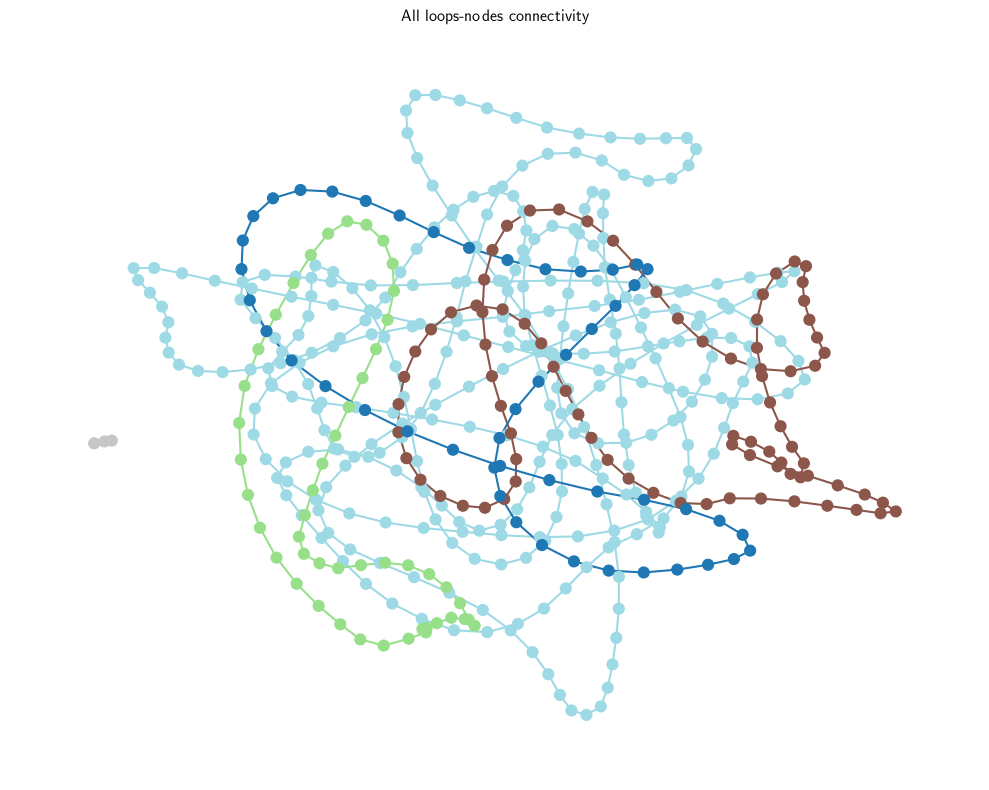

Found 1 junctions
Junction between nodes 1469 and 2278 connecting loops [61, 63]


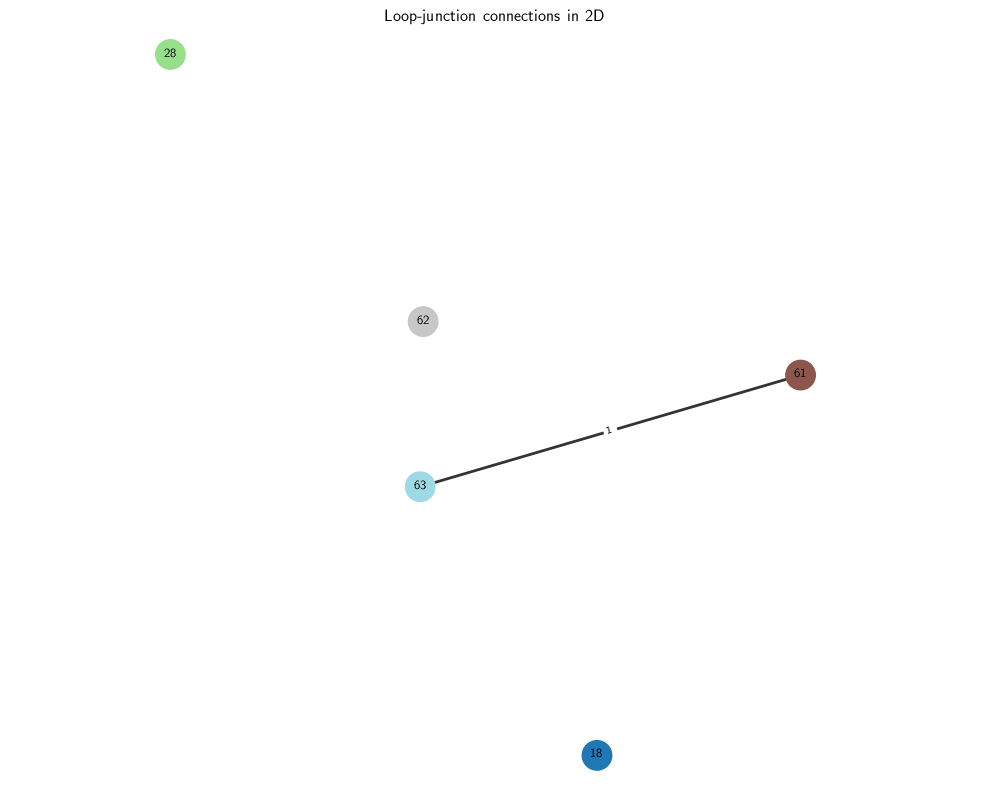

In [ ]:
# -----------------------------
# User Settings
# -----------------------------
# from tests.networkGraph.lib.utilitiesDD import plot_loops_3d


simulationDir = os.path.join("../..", "tutorials", "shearDensityFCC")
evl_file = 7290;

# -----------------------------
# Setup MoDELib objects  
# -----------------------------
evl_dir = os.path.join(simulationDir, "evl")
ddBase = pyMoDELib.DislocationDynamicsBase(simulationDir)
ddio   = pyMoDELib.DDconfigIO(evl_dir)
defectiveCrystal = pyMoDELib.DefectiveCrystal(ddBase)
xMin = np.array(ddBase.mesh.xMin(), dtype=float)
xMax = np.array(ddBase.mesh.xMax(), dtype=float)
ddio.readTxt(evl_file)
defectiveCrystal.initializeConfiguration(ddio)
DN = defectiveCrystal.dislocationNetwork()

# ------------------------------
# Output Dir
# ------------------------------
fig_dir = os.path.join(simulationDir, "figures")
os.makedirs(fig_dir, exist_ok=True)


# --------------------------------
# segments with node IDs + node positions + loopIDs
# -------------------------------- 
segments_info, skipped = build_segments(DN)
segment_loopIDs = set()
for s in segments_info:
    print(s["link_key"], "source ID:", s["source_id"], ", position:", s["source_pos"], ", is on boundary:", s["source_is_boundary"])
    print("         ", "sink ID:", s["sink_id"], ", position", s["sink_pos"],  ", is on boundary:", s["sink_is_boundary"])
    print("         ", "segment burgers:", s["burgers"], ", segment glide plane normal:", s["glidePlaneNormal"], ", loops segment belongs to:", s["loopIDs"])
    segment_loopIDs |= s["loopIDs"]
print("Unique loop IDs from segments:", segment_loopIDs)

# --------------------------------
# loops -> ordered loop nodes -> their positions 
# -------------------------------- 
loops = build_loops(ddio, filter_loopIDs=segment_loopIDs)
plot_loops_3d(loops, xMin, xMax, outpath=os.path.join(fig_dir, f"loops_{evl_file:08d}.png"), title=rf"EVL {evl_file}")


# -------------------------
# Network X Graph of Loop-Nodes Connections
# -------------------------
loop_graphs, G_loops_all, pos = build_loop_graphs_from_loops_dict(loops, close=True)
print(f"Total nodes in all loops: {G_loops_all.number_of_nodes()}")
print(f"Total loop edges: {G_loops_all.number_of_edges()}")
for lid, Gl in loop_graphs.items():
    print(f"loop {lid}: nodes={Gl.number_of_nodes()} edges={Gl.number_of_edges()}")
plot_all_loops_connectivity_2d(G_loops_all, show_labels=False)


# -------------------------
# Get Junctions 
# -------------------------
junctions, loop_to_jlinks = find_junction_network_links(DN, skip_zeroB=True, skip_boundary=True)
print(f"Found {len(junctions)} junctions")
for j in junctions:
    print("Junction between nodes", j["source_nID"], "and", j["sink_nID"], "connecting loops", j["loopIDs"])


# -------------------------
# Network X Graph of Loop-Junction connections 
# -------------------------
G_LJ = build_loop_junction_graph(junctions,loops.keys())
pos2d = loop_centroids_2d(loops, plane="xy")  # change to 'xz' or 'yz' if you want
plot_loops_and_junctions_2d(G_LJ, pos2d, show_edge_counts=True)